In [2]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


Text(0, 0.5, 'count')

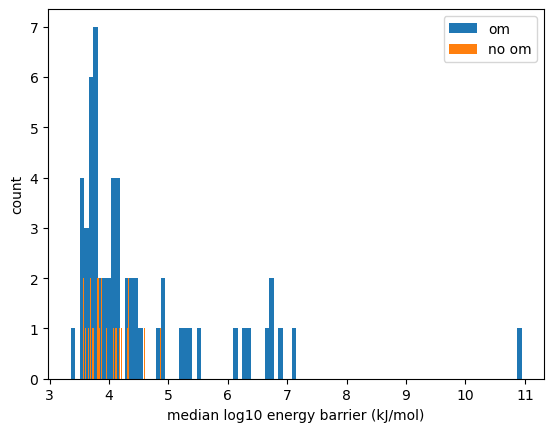

In [3]:
import torch
import numpy as np
from openmm.app import *
from openmm import *
from openmm.unit import *
import matplotlib.pyplot as plt
from pdbfixer import PDBFixer
import io
from io import StringIO
import mdtraj as md
from tqdm import tqdm
import os

# Compute energy barriers for all tetrapeptides
exp_name = "main_eval_output_om_interpolate_test_april8_model_fulldataset_dt=0.0002_flowmatching"
path = "saved_models/tetrapeptides_all_atom/" + exp_name
energies  = []
for file in os.listdir(path):
    if file.endswith(".pt") and "energies" in file:
        file_name = os.path.join(path, file)
        en = torch.load(file_name)
        energies.append(en.max(1)[0].cpu().log10().mean())

out = plt.hist(energies, bins=100, label="om")

exp_name = "main_eval_output_interpolate_test_latent_time=7_flowmatching"
path = "saved_models/tetrapeptides_all_atom/" + exp_name
energies  = []
for file in os.listdir(path):
    if file.endswith(".pt") and "energies" in file:
        file_name = os.path.join(path, file)
        en = torch.load(file_name)
        energies.append(en.max(1)[0].cpu().log10().median())

out = plt.hist(energies, bins=100, label="no om")
plt.legend()
plt.xlabel("median log10 energy barrier (kJ/mol)")
plt.ylabel("count")




        

  


In [4]:
import mdtraj as md
iid_samples = torch.load("/home/sanjeevr/om-diffusion/two-for-one-diffusion/saved_models/tetrapeptides_all_atom/main_eval_output_iid_test_april12_model_no_padding_50steps_flowmatching/sample-iid_AVGR.pt")

iid_samples.shape

true_samples = md.load("/data/sanjeevr/4AA_sim/AVGR/AVGR.xtc", top="/data/sanjeevr/4AA_sim/AVGR/AVGR.pdb").xyz[::100]
true_samples.shape

npy_samples = np.load("/data/sanjeevr/4AA_sim/AVGR_i100.npy") / 10
npy_samples.shape

(10000, 4, 14, 3)

In [5]:
npy_samples = npy_samples[0].reshape(-1)
npy_samples_first = npy_samples[npy_samples != 0].reshape(-1, 3)

true_samples_first = true_samples[0]


In [6]:
npy_samples_first.shape, true_samples_first.shape

((27, 3), (28, 3))

In [48]:
iid_samples_first = iid_samples[0]

In [51]:
# investigate the energies of both of these samples to see if PDB fixer is leading to high energies
incomplete_topology = md.load_topology("/home/sanjeevr/om-diffusion/two-for-one-diffusion/saved_models/tetrapeptides_all_atom/main_eval_output_iid_test_april12_model_no_padding_flowmatching/AVGR_0.pdb")
incomplete_sample = md.Trajectory(npy_samples_first[None], topology=incomplete_topology)
incomplete_sample.save_pdb("temp.pdb")


In [14]:
from evaluate.compute_tetra_energies import fix_pdb_file, compute_energies

# fix_pdb_file("temp.pdb")
print(compute_energies("/home/sanjeevr/om-diffusion/two-for-one-diffusion/saved_models/tetrapeptides_all_atom/main_eval_output_iid_test_april12_model_no_padding_flowmatching/AVGR_0.pdb", compute_freq = 1000))


Adding Missing Heavy Atoms and Hydrogens to PDB File


100%|██████████| 10000/10000 [00:09<00:00, 1005.37it/s]


Computing energies with RMSD thresholding...


1it [00:00,  2.69it/s]

Frame 0: Energy = 2354.38 kJ/mol | RMSD = 0.096 Å


...

Frame 8: Energy = -453.00 kJ/mol | RMSD = 0.214 Å


10it [00:05,  1.87it/s]

Frame 9: Energy = -448.06 kJ/mol | RMSD = 0.203 Å


11it [00:05,  1.92it/s]

Frame 10: Energy = 826.29 kJ/mol | RMSD = 0.096 Å
[2354.37753296  101.96173096 -640.98382568 -521.00668335 1520.66967773
 -506.19276428 -572.12039185 -621.33956909 -453.00183105 -448.06303406
  826.29124451]


In [ ]:
print(compute_energies("temp.pdb"))

In [37]:
complete_topology = md.load_topology("/data/sanjeevr/4AA_sim/AVGR/AVGR.pdb")
complete_sample = md.Trajectory(true_samples_first[None], topology=complete_topology)
complete_sample.save_pdb("temp_complete.pdb")

print(compute_energies("temp_complete.pdb"))

Adding Missing Heavy Atoms and Hydrogens to PDB File


  0%|          | 0/1 [00:00<?, ?it/s]

100%|██████████| 1/1 [00:00<00:00,  2.16it/s]


Computing energies...


1it [00:00,  3.60it/s]

[-446.20278931]


In [ ]:
complete_topology = md.load_topology("/data/sanjeevr/4AA_sim/AVGR/AVGR.pdb")
complete_sample = md.load_pdb(true_samples_first[None], topology=complete_topology)
complete_sample.save_pdb("temp_complete.pdb")

print(compute_energies("temp_complete.pdb"))

In [12]:
out = compute_energies("AVGR_temp.pdb", compute_freq=500)


Adding Missing Heavy Atoms and Hydrogens to PDB File


100%|██████████| 1000/1000 [00:03<00:00, 263.18it/s]


Computing energies...


0it [00:00, ?it/s]

> /home/sanjeevr/om-diffusion/two-for-one-diffusion/evaluate/compute_tetra_energies.py(99)compute_energies()
     97             diffs = initial_pos - minimized_pos
     98             import pdb; pdb.set_trace()
---> 99             rmsd = np.sqrt(np.mean(np.sum(diffs**2, axis=1)))
    100             print(f"Frame {i}: Energy = {potential_energy:.2f} kJ/mol | RMSD = {rmsd:.3f} Å")
    101 

(60, 3)
(60, 3)


0it [00:13, ?it/s]


(-1000.0, 1000.0)

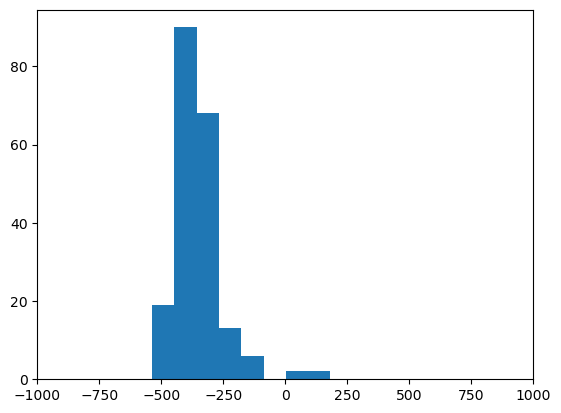

In [11]:
plt.hist(out, bins=100)
plt.xlim(-1000, 1000)

In [31]:
npy_samples_first * 10

array([[-1.59  ,  0.43  , -0.3398],
       [-0.6797,  1.63  , -0.3   ],
       [ 0.76  ,  1.23  , -0.12  ],
       [ 1.06  ,  0.14  ,  0.46  ],
       [-1.13  ,  2.55  ,  0.85  ],
       [ 1.65  ,  2.11  , -0.6   ],
       [ 3.102 ,  2.04  , -0.26  ],
       [ 3.34  ,  2.35  ,  1.25  ],
       [ 2.79  ,  3.35  ,  1.789 ],
       [ 3.902 ,  3.05  , -1.13  ],
       [ 5.383 ,  3.34  , -0.6895],
       [ 4.01  ,  2.52  , -2.53  ],
       [ 4.29  ,  1.6   ,  1.89  ],
       [ 4.81  ,  1.789 ,  3.168 ],
       [ 6.25  ,  2.21  ,  3.121 ],
       [ 7.23  ,  1.43  ,  3.18  ],
       [ 6.375 ,  3.512 ,  2.93  ],
       [ 7.71  ,  4.18  ,  2.84  ],
       [ 7.66  ,  5.5   ,  3.63  ],
       [ 6.8   ,  6.41  ,  3.42  ],
       [ 8.28  ,  4.29  ,  1.379 ],
       [ 9.82  ,  4.59  ,  1.28  ],
       [10.34  ,  4.6   , -0.14  ],
       [11.76  ,  4.84  , -0.19  ],
       [12.67  ,  4.13  , -0.8896],
       [12.34  ,  3.082 , -1.47  ],
       [13.97  ,  4.43  , -0.81  ]], dtype=float16)

In [42]:
incomplete_topology

<mdtraj.Topology with 1 chains, 4 residues, 27 atoms, 26 bonds at 0x7f84814e44d0>

In [43]:
complete_topology

<mdtraj.Topology with 1 chains, 4 residues, 28 atoms, 27 bonds at 0x7f847f36bd70>

TypeError: Topology.atoms_by_name() missing 1 required positional argument: 'name'